In [1]:
import sys
from pathlib import Path

# 🔑 Automatically locate project root by searching upward for the 'src' folder
project_root = Path.cwd()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent

# Insert at the front of sys.path so Python finds 'src' first
sys.path.insert(0, str(project_root))
print(f"✅ Project root resolved: {project_root}")

✅ Project root resolved: c:\Users\igor\Documents\GitHub\futures_trading_strategies


In [2]:
import pandas as pd
from src import (
    load_simple_price_csv,
    VectorizedEngine,
    FixedRiskPositionStrategy,
    plot_results,
    plot_backtest_results
)

In [3]:
data = load_simple_price_csv("../data/MCFTR.csv", date_format="%Y-%m-%d")
display(data.head())

2026-08-04 09:40:16.652 | INFO     | src.data.loader:load_simple_price_csv:47 - 📥 Loading simple price data: MCFTR.csv
2026-08-04 09:40:16.662 | INFO     | src.data.loader:load_simple_price_csv:81 - ✅ Loaded 5739 bars | Range: 2003-02-26 → 2026-02-13


,close
date,
2003-02-26,335.67
2003-02-27,338.35
2003-02-28,341.52
2003-03-03,352.24
2003-03-04,348.40


In [17]:
INITIAL_CAPITAL = 100000
VOLATILITY_WINDOW = 63
RISK_TARGET = 0.1
MULTIPLIER=1.0
MAX_LEVERAGE=1
COMMISSION_RATE=0.0005
SLIPPAGE_RATE=0.0005

In [18]:
engine = VectorizedEngine(
    initial_capital=INITIAL_CAPITAL,     
    commission_rate=COMMISSION_RATE,
    slippage_rate=SLIPPAGE_RATE
)

In [ ]:
strategy = FixedRiskPositionStrategy(volatility_window=VOLATILITY_WINDOW, risk_target=RISK_TARGET, max_leverage=MAX_LEVERAGE)
strategy2 = FixedRiskPositionStrategy(vol_method="blended", short_span=31, long_span=2520, risk_target=RISK_TARGET, max_leverage=MAX_LEVERAGE)

In [28]:
result = engine.run(strategy, data)
result2 = engine.run(strategy2, data)

In [29]:
result.print_summary()
result2.print_summary()

┌──────────────────────────────────────────────────────────────────────
│ Strategy: FixedRiskPositionStrategy                │ Instrument               │
├──────────────────────────────────────────────────────────────────────┤
│ Years of data                            │                     22.8 │
│ Mean annual return                       │                    +8.2% │
│ Average drawdown                         │                    -1.2% │
│ Maximum drawdown                         │                   -16.0% │
│ Annualised standard deviation            │                    10.9% │
│ Sharpe ratio                             │                     0.75 │
│ Skew                                     │                     0.00 │
│ Lower tail                               │                     1.66 │
│ Upper tail                               │                     1.25 │
└──────────────────────────────────────────────────────────────────────┘
┌───────────────────────────────────────────────────

c:\Users\igor\Documents\GitHub\futures_trading_strategies\src\plots\plot_backtest_results.py:198: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


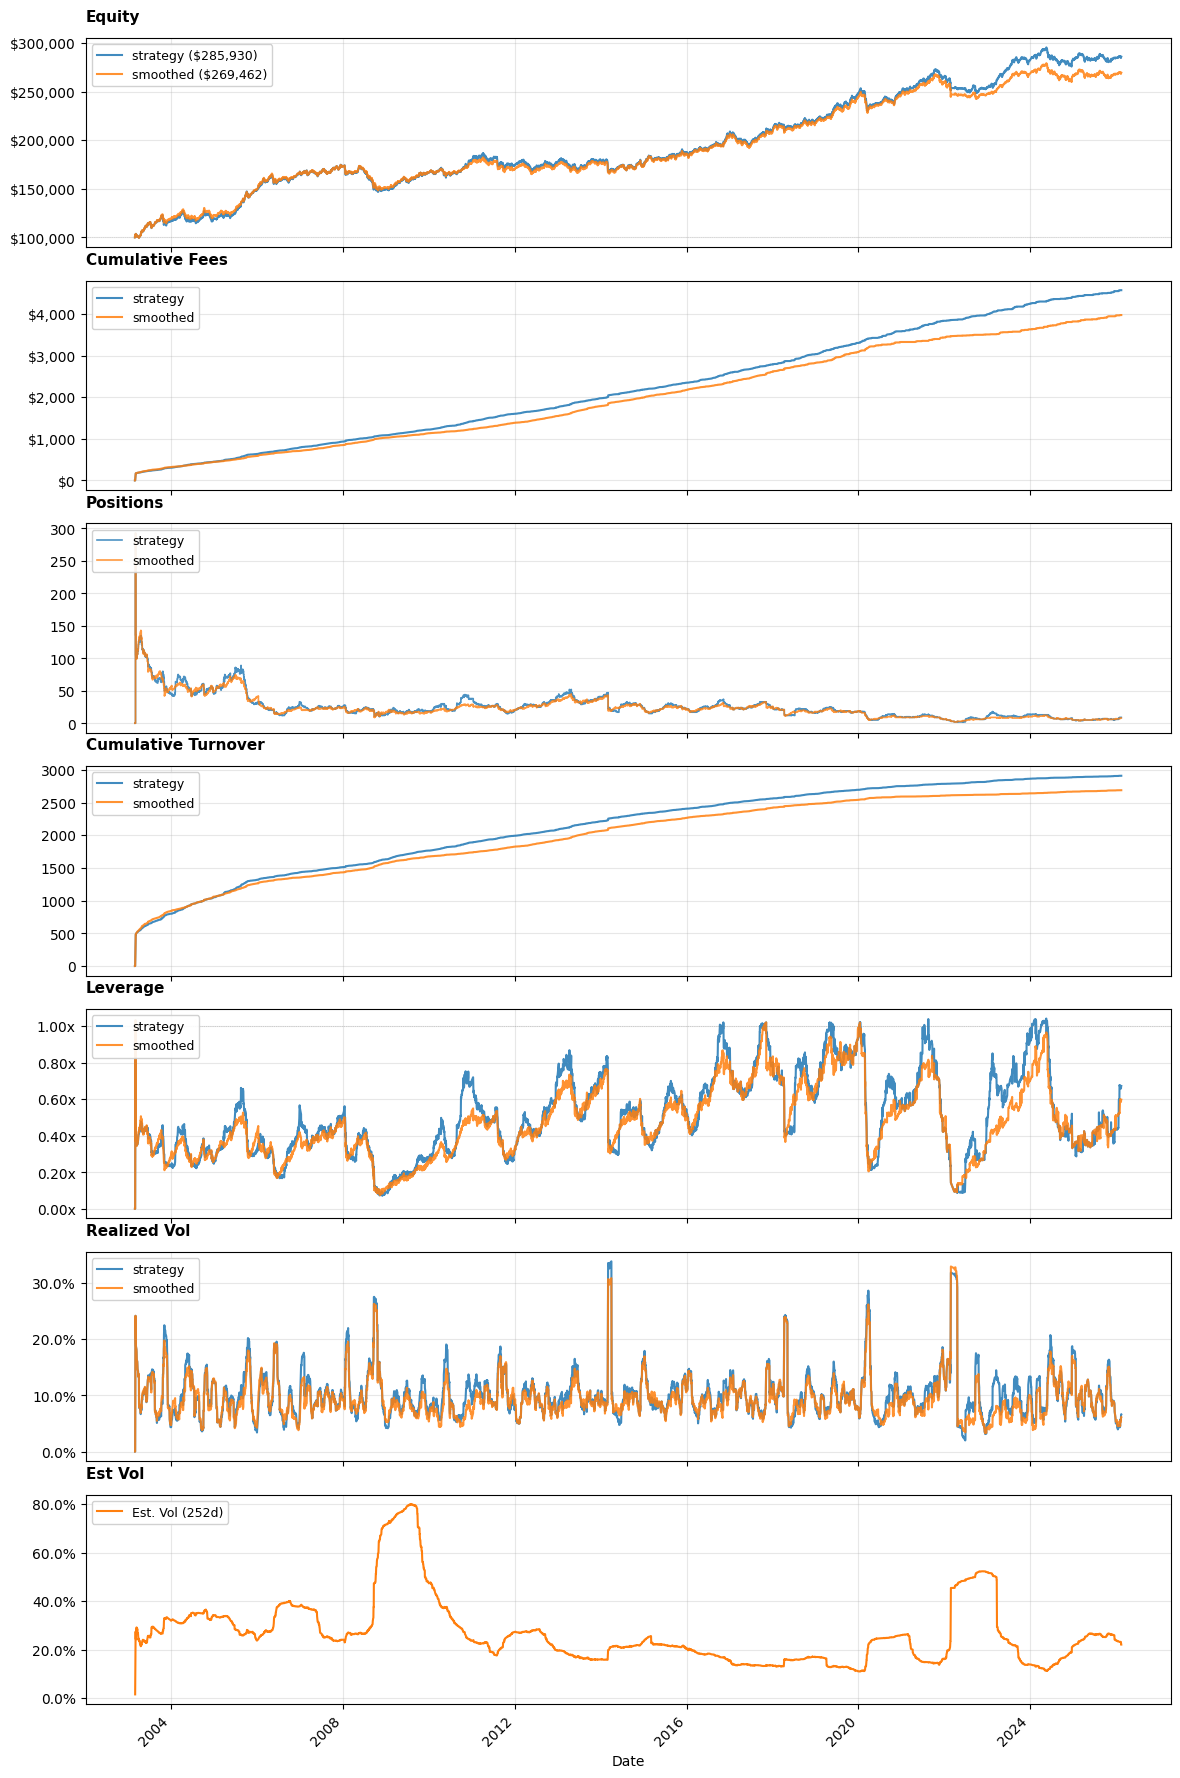

In [30]:
plot_backtest_results(
    results={"strategy": result, "smoothed": result2},
    panels=['equity', 'cumulative_fees', 'positions','cumulative_turnover', 'leverage', "realized_vol", "est_vol"],
    data=data,
    plot_pct=False,
    figsize_base=(14, 2.8)  # Slightly taller panels
)